In [4]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [11]:
# Categorise stock price movements based on percent changes

def classify_movements(percent_return):
    """
    This function categorises a stock movement between two days
    based on % change.
    """
    if percent_return > -0.3 and percent_return <= 0.3:
        return 'Negligible change'
    elif percent_return > 0.3 and percent_return <= 3:
        return 'Up'
    elif percent_return > -3 and percent_return <= -0.3:
        return 'Down'
    elif percent_return > 3 and percent_return <= 7:
        return 'Up+++'
    elif percent_return > -7 and percent_return <= -3:
        return 'Down---'
    elif percent_return > 7:
        return 'Bull Run'
    elif percent_return <= -7:
        return 'Bear Sell off'

def visualise_stock_movement(TCKR, period):
    """
    This function imports data using yfinance, calculates % change
    in stock value (closing prices) between two days and shows a time 
    series plot and a pie chart with the movements based on the values
    described in classify_movements function.
    """
    stock = yf.Ticker(TCKR)
    stock_df = stock.history(period=period)
    
    stock_df["Daily Return"] = stock_df['Close'].pct_change(1) * 100
    stock_df['Daily Return'].replace(np.nan, 0, inplace = True)

    stock_df['Trend'] = stock_df['Daily Return'].apply(classify_movements)
    stock_movements = stock_df['Trend'].value_counts()

    # Creating the layout of the figure
    fig = make_subplots(rows=2, cols=1, row_heights=[0.55, 0.45],
        specs=[[{"type": "xy"}],[{"type": "domain"}]],
        subplot_titles=[TCKR+" Closing Price [$]", "Stock movement Summary"])

    # Plot time series on the top panel
    fig.add_trace(
        go.Scatter(x=stock_df.index,y=stock_df["Close"], mode="lines", name="Close"),
        row=1, col=1)

    # Plot the pie chart in the bottom panel
    fig.add_trace(
        go.Pie(labels=stock_movements.index,values=stock_movements),
        row=2, col=1)

    # Layout tweaks
    fig.update_layout(template="plotly_white",height=800, showlegend=True)

    fig.update_traces(textinfo="percent+label",hoverinfo="label+percent",row=2, col=1)

    fig.show()
    
    #fig.add_scatter(x = nvda_df.index, y = nvda_df['Close'], name = 'Close')
    #stock_movements.plot(kind = 'pie', y = 'Stock Movements')

/var/folders/zd/5tclx9553z5cr_l9rz0l5svc0000gr/T/ipykernel_98679/309461961.py:34: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





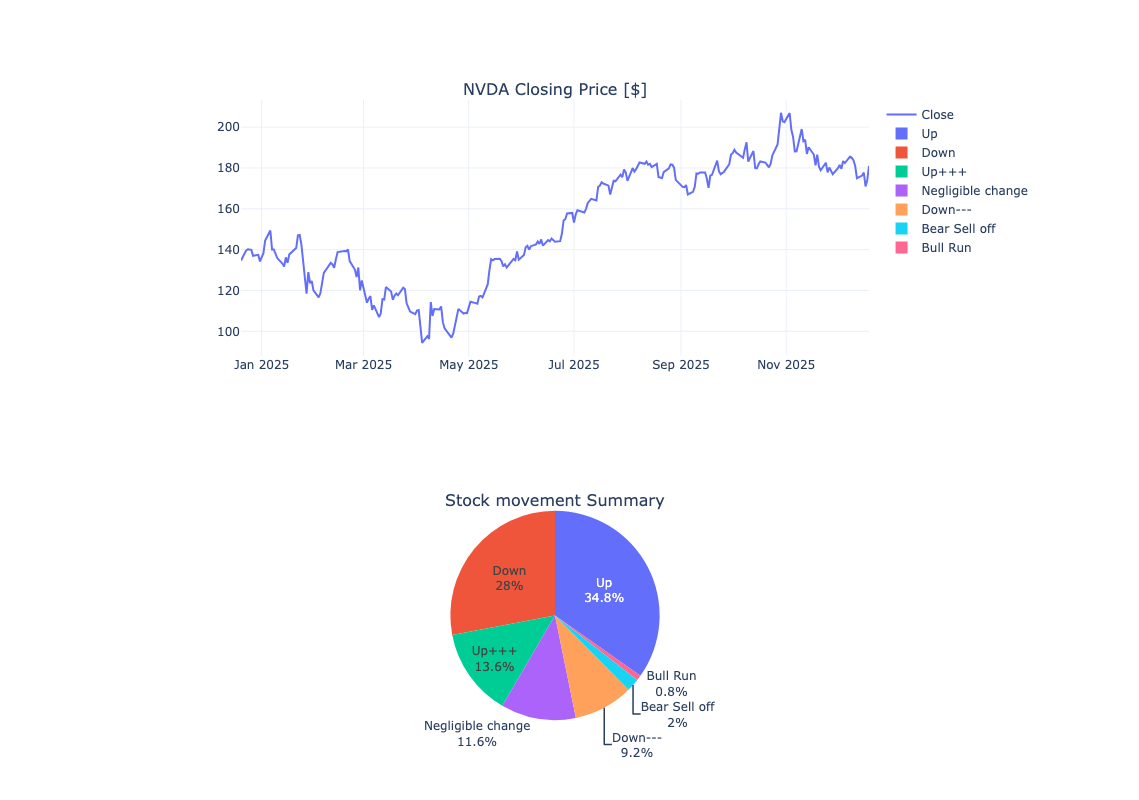

In [12]:
visualise_stock_movement("NVDA", "1y")